In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import math

import keras
from keras import models
from keras import layers
from keras import optimizers
from keras.models import Sequential
from keras.layers import Dense, Conv2D , SeparableConv2D, MaxPooling2D , Flatten , Dropout , BatchNormalization, Activation
from keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from keras.callbacks import ReduceLROnPlateau
from keras import backend as K
from keras import optimizers
from sklearn.metrics import classification_report, recall_score, precision_score, confusion_matrix, f1_score, accuracy_score
import tensorflow as tf

In [ ]:
train_data_dir = '/content/gdrive/MyDrive/Fine dataset/train/'
test_data_dir = '/content/gdrive/MyDrive/Fine dataset/test/'

In [ ]:
train_datagen = ImageDataGenerator(
        rescale=1./255,
        # zoom_range=0.4,
        validation_split=0.2
        )

train_gen = train_datagen.flow_from_directory(
        directory = train_data_dir,
        target_size=(256, 256),
        batch_size=32,
        class_mode='categorical',
        subset='training'
        )
val_gen = train_datagen.flow_from_directory(
        directory = train_data_dir,
        target_size=(256, 256),
        batch_size=32,
        class_mode='categorical',
        subset='validation'
        )

Found 1383 images belonging to 3 classes.
Found 345 images belonging to 3 classes.


In [ ]:
test_datagen = ImageDataGenerator(
        rescale=1./255
        )
y_act = test_datagen.flow_from_directory(
    directory = test_data_dir,
    target_size=(256,256),
    batch_size = 32,
    class_mode = 'categorical',
    shuffle = True
)

Found 157 images belonging to 3 classes.


In [ ]:
image_size = (256,256,3)

In [ ]:
resnet_XrayPn_model = Sequential()

pretrained_model = tf.keras.applications.ResNet50(
                    include_top=False,
                    weights="imagenet",
                    input_shape=image_size,
                    pooling='avg',
                    classes=3,

)
for layer in pretrained_model.layers:
        layer.trainable = False

resnet_XrayPn_model.add(pretrained_model)
resnet_XrayPn_model.add(Flatten())
resnet_XrayPn_model.add(Dense(512, activation ='relu'))
resnet_XrayPn_model.add(Dense(3,activation='softmax'))


In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 127, 127, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 62, 62, 64)       0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 246016)            0         
                                                                 
 dense (Dense)               (None, 128)               3

In [ ]:
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics = ['acc'])

In [ ]:
from keras.callbacks import EarlyStopping
Early_stop = EarlyStopping(monitor = 'val_acc',patience = 10)

In [ ]:
history = model.fit(train_gen, validation_data=val_gen, epochs=50, callbacks=[Early_stop])

Epoch 1/50
44/44 [==============================] - 473s 11s/step - loss: 1.1898 - acc: 0.4237 - val_loss: 0.9724 - val_acc: 0.5942
Epoch 2/50
44/44 [==============================] - 347s 8s/step - loss: 0.9259 - acc: 0.5481 - val_loss: 0.8234 - val_acc: 0.7449
Epoch 3/50
44/44 [==============================] - 351s 8s/step - loss: 0.9185 - acc: 0.5951 - val_loss: 0.8312 - val_acc: 0.5913
Epoch 4/50
44/44 [==============================] - 351s 8s/step - loss: 0.8561 - acc: 0.6052 - val_loss: 0.7140 - val_acc: 0.7710
Epoch 5/50
44/44 [==============================] - 349s 8s/step - loss: 0.7300 - acc: 0.6847 - val_loss: 0.7063 - val_acc: 0.7594
Epoch 6/50
44/44 [==============================] - 351s 8s/step - loss: 0.7218 - acc: 0.6645 - val_loss: 0.6847 - val_acc: 0.7391
Epoch 7/50
44/44 [==============================] - 349s 8s/step - loss: 0.6844 - acc: 0.6970 - val_loss: 0.7154 - val_acc: 0.7565
Epoch 8/50
44/44 [==============================] - 349s 8s/step - loss: 0.6540 - 

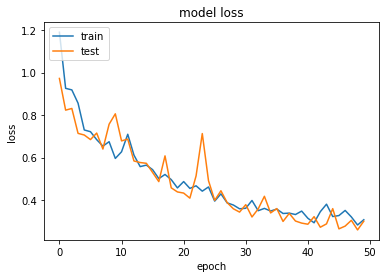

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

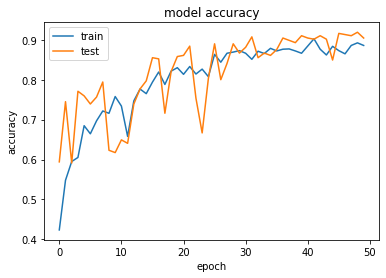

In [ ]:
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

              precision    recall  f1-score   support

           C       0.80      0.71      0.75       164
           N       0.89      0.85      0.87       164
           P       0.70      0.79      0.74       164

   micro avg       0.79      0.79      0.79       492
   macro avg       0.79      0.79      0.79       492
weighted avg       0.79      0.79      0.79       492



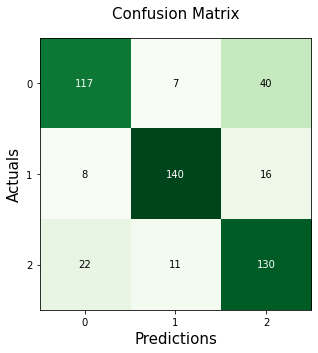

In [ ]:
from matplotlib import pyplot as plt
print(metrics.classification_report(y_act, y_pred, labels=["C", "N", "P"]))
from mlxtend.plotting import plot_confusion_matrix

fig, ax = plot_confusion_matrix(metrics.confusion_matrix( y_act, y_pred, labels=["C", "N", "P"]), figsize=(5, 5), cmap=plt.cm.Greens)
plt.xlabel('Predictions', fontsize=15)
plt.ylabel('Actuals', fontsize=15)
plt.title('Confusion Matrix', fontsize=15)
plt.show()

In [ ]:
import numpy as np
from sklearn import metrics
# Predicted values
y_pred = ["P", "N", "N",   "P", "N", "N",   "P", "N", "P",    "P", "N", "P",    "P", "N", "P",   "P", "P", "C",   "N", "N", "N",  "P", "N", "C",   "N", "N", "C",   "P", "N", "C",   "N", "C", "C",   "N", "P", "C",   "P", "N", "C",   "P", "N", "C",   "P", "N", "C",   "P", "N", "C",   "C", "P", "C",   "N", "C", "C",   "N", "C", "C",   "P", "C", "c",   "P", "P", "N",   "P", "P", "N",  "N", "C", "C",   "P", "P", "P", "P", "N", "P",
         "P", "P", "N",   "P", "C", "N",   "P", "P", "C",   "P", "P", "N",   "P", "C", "C",   "P", "P", "N",  "P", "P", "C",    "P", "N", "C",   "P", "C", "N",   "P", "P", "C",   "P", "N", "P",   "P", "N", "P",  "P", "N", "P",   "P", "N", "P",   "P", "N", "P",   "P", "N", "P",   "P", "N", "C",   "C", "N", "C",   "P", "P", "N",   "P", "P", "C",   "P", "P", "P",  "P", "P", "P",  "P", "N", "P",  "P", "N", "P","C", "N", "P",
         "C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P",
         "C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P",
         "C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P",
         "C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P", "C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P", "C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P", "C", "N", "P","C", "N", "P", "C", "N", "P", "C", "N", "P"]
# Printing the confusion matrix
# Actual values
y_act = ["C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P",
         "C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P",
         "C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P",
         "C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P",
         "C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P",
         "C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P", "C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P", "C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P","C", "N", "P", "C", "N", "P","C", "N", "P", "C", "N", "P", "C", "N", "P"]